In [35]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import mdata_utils

# GEX

In [36]:
GSE = 'GSE156718'
data_path = "/ix1/ylee/Yifan_Zhang/Code_data/external/GSE156718 CD4 iLN"
mdata_ori = mu.read(data_path + "/GSE156718.h5mu")
mdata = mdata_ori.copy()

In [37]:
mdata

MuData object with n_obs × n_vars = 11856 × 31053
  obs:	'batch'
  2 modalities
    airr:	11856 x 0
      obsm:	'airr'
    gex:	11856 x 31053
      obs:	'TCR_clonotype_frequency', 'tissue', 'sample_id', 'mouse_id'

In [38]:
%cd $data_path

/ix1/ylee/Yifan_Zhang/Code_data/external/GSE156718 CD4 iLN


In [39]:
mdata.obs['GSE'] = GSE
mdata.obs['GSM'] = mdata.obs['batch']
mdata.obs['tissue'] = mdata['gex'].obs['tissue']


In [40]:
mdata['gex'].obs['tissue'].value_counts()

tissue
iLN       3260
mLN       3132
Spleen    2506
CNS        413
Name: count, dtype: int64

In [41]:
mdata = mdata_utils.pp_EAE(mdata, celltype_score = 0.4, cellstate_score = 0.4, topN_variable = None)

In [42]:
print(mdata['gex'].obs['cell_type'].value_counts())
print(mdata['gex'].obs['state'].value_counts())

cell_type
CD4         2980
CD4_Treg     315
CD8          223
CD4_Th17      15
CD4_Th2        1
CD4_Th1        1
Name: count, dtype: int64
state
Early_activ        1586
Naive               483
Memory_core         470
Proliferating       406
Exhaustion_core     362
Tcf7_stem           356
IFN_stim            165
Cytotoxic           121
Effector_core        29
Name: count, dtype: int64


In [43]:
## data specific features
mdata.obs['condition'] = 'EAE'


In [44]:
sc.pp.pca(mdata["gex"], n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)

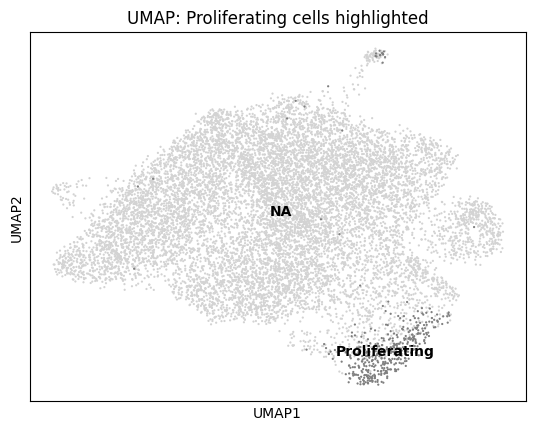

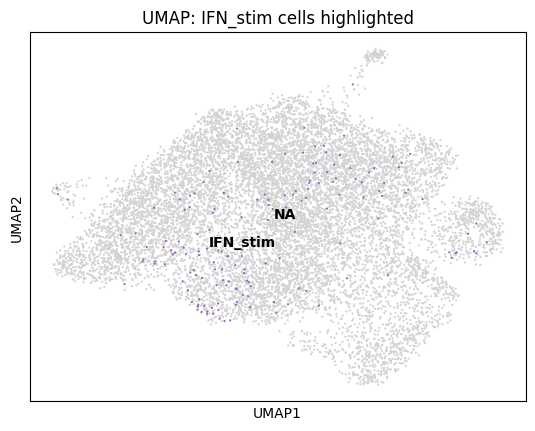

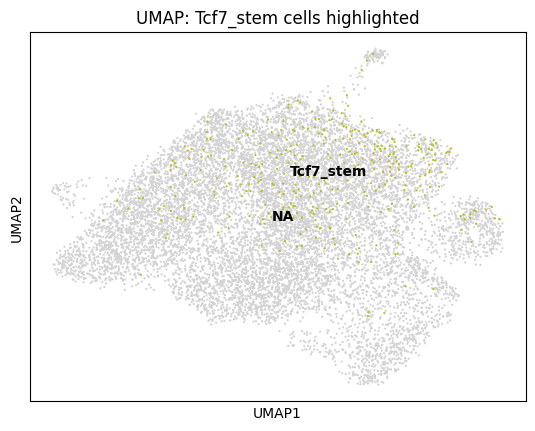

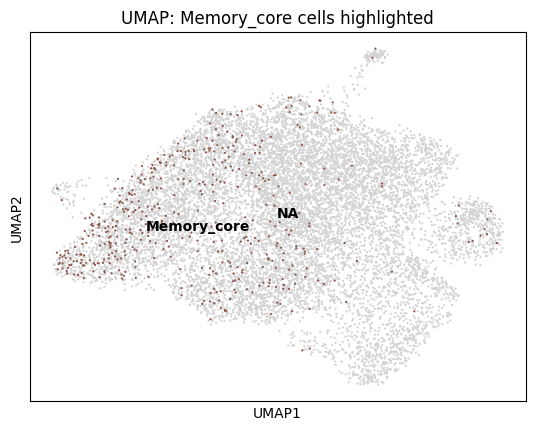

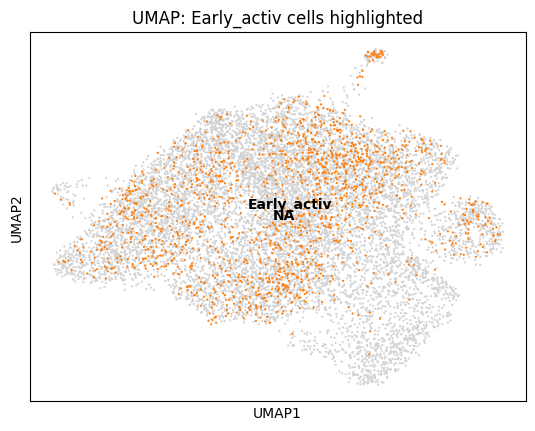

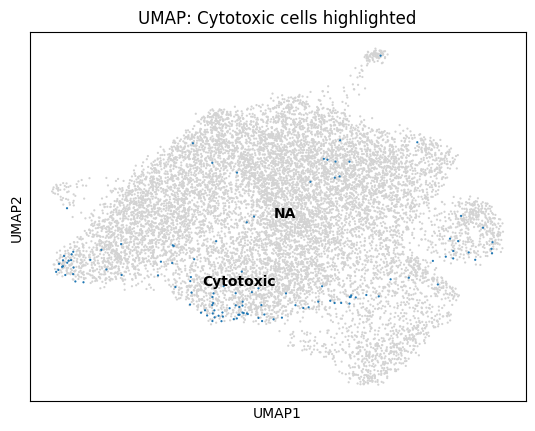

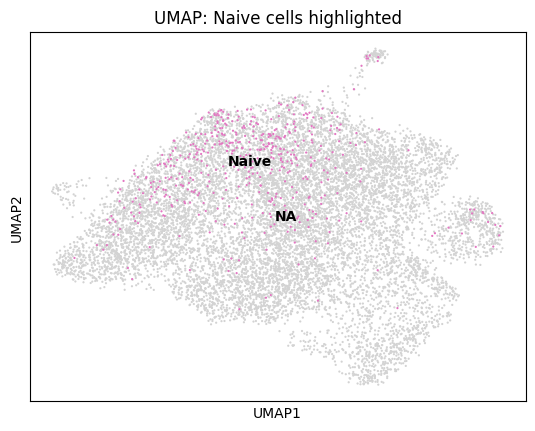

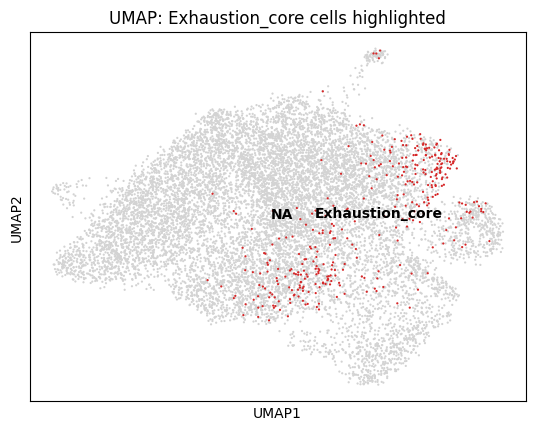

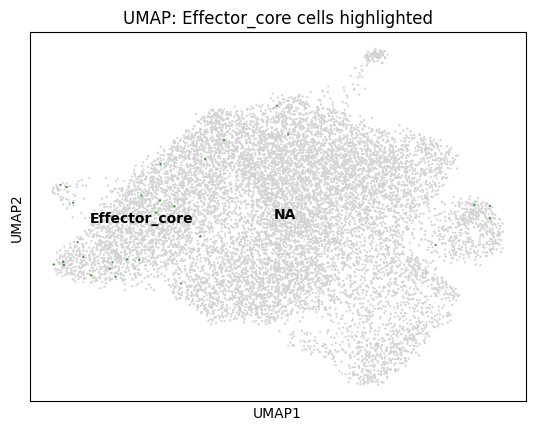

In [45]:
for state_cat in mdata["gex"].obs['state'].dropna().unique():
    sc.pl.umap(
        mdata["gex"], 
        color='state', 
        groups=[state_cat], 
        title=f"UMAP: {state_cat} cells highlighted",
        legend_loc='on data',
        ncols=2
    )

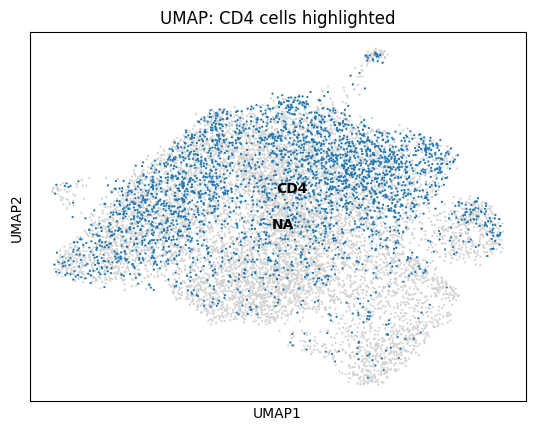

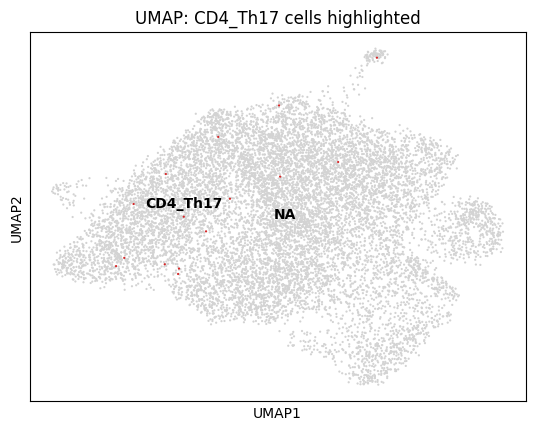

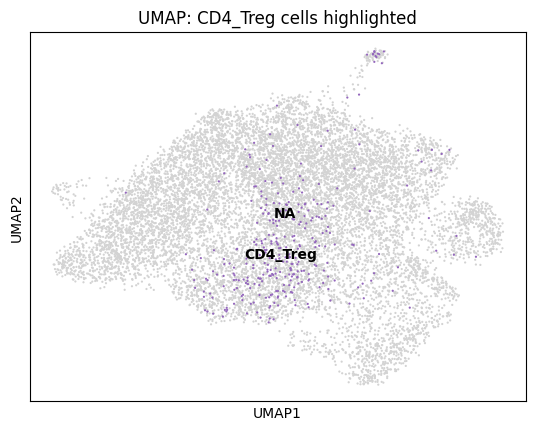

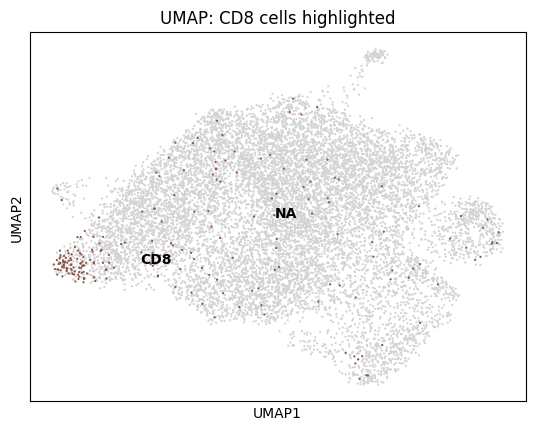

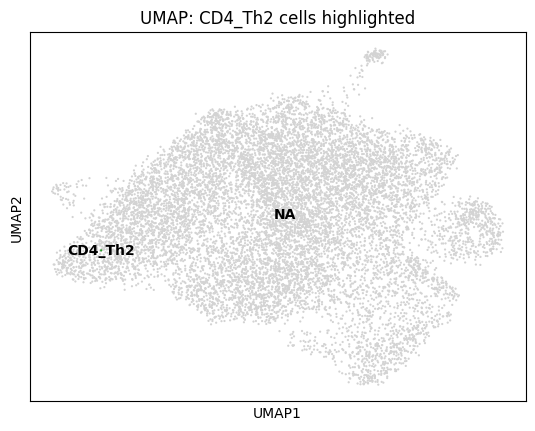

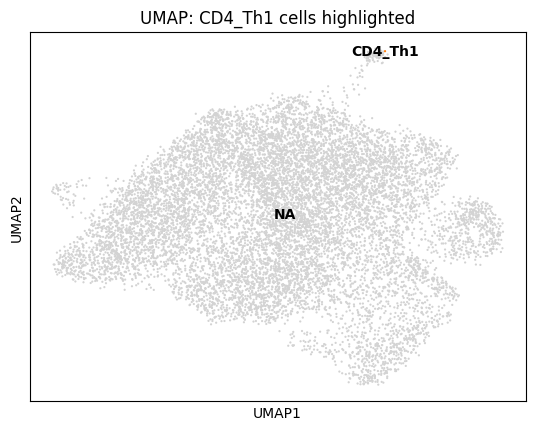

In [46]:
for state_cat in mdata["gex"].obs['cell_type'].dropna().unique():
    sc.pl.umap(
        mdata["gex"], 
        color='cell_type', 
        groups=[state_cat], 
        title=f"UMAP: {state_cat} cells highlighted",
        legend_loc='on data',
        ncols=2
    )

# TCR Clonotypes

In [47]:
# mdata = mdata_ori.copy()
mdata['airr'].obs['sample_id'] = mdata['gex'].obs['sample_id']

ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only", within_group = 'sample_id')

meta_airr = ir.get.airr(mdata['airr'], ["cdr3_aa", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))

df2_filtered = meta_airr.loc[:, ~meta_airr.columns.isin(mdata.obs.columns)]
mdata.obs = mdata.obs.join(df2_filtered)
mdata.update()

# mdata.obs = mdata.obs.reindex(mdata.mod['gex'].obs.index)
ir.tl.clonal_expansion(mdata)


In [48]:
mdata

MuData object with n_obs × n_vars = 11856 × 30799
  obs:	'batch', 'GSE', 'GSM', 'tissue', 'state', 'cell_type', 'sample_id', 'condition', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call'
  2 modalities
    airr:	11856 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'
    gex:	11856 x 30799
      obs:	'TCR_clonotype_frequency', 'tissue', 'sample_id', 'mouse_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'CD4_score', 'CD8_score', 'cell_type', 'Treg_score', 'Th1_score', 'Th2_score', 'Th17_score', 'Naive_score', 'Cytotoxic_score', 'Exhaustion_core_score', 'Tcf7_stem_score', 'Proliferating_score', 'IFN_stim_score', 'Early_activ_score', 'Memory_core_score', 'Effector_core_score', 'state'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'state_colors', 'cell_type_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'

In [49]:
count = (mdata['airr'].obs['clone_id_size'] == 1).sum()
print(count)

9550


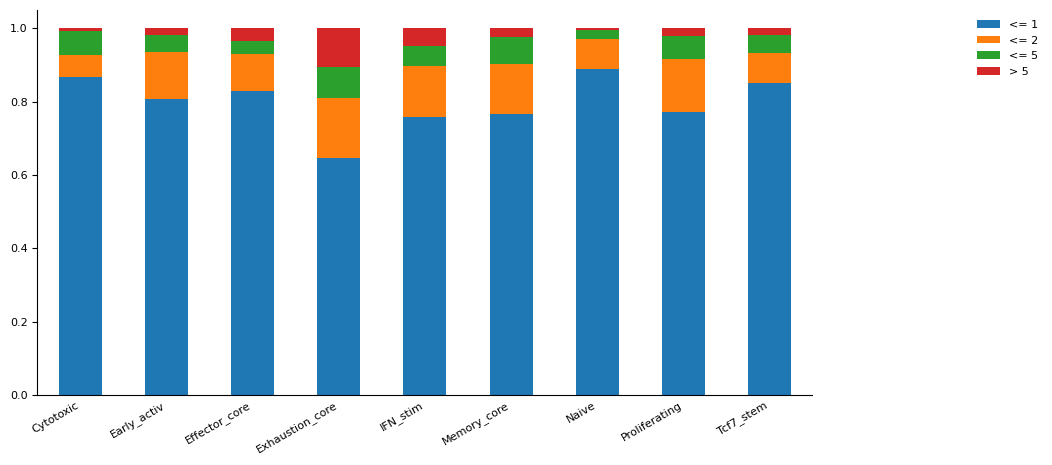

In [50]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby="state",  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

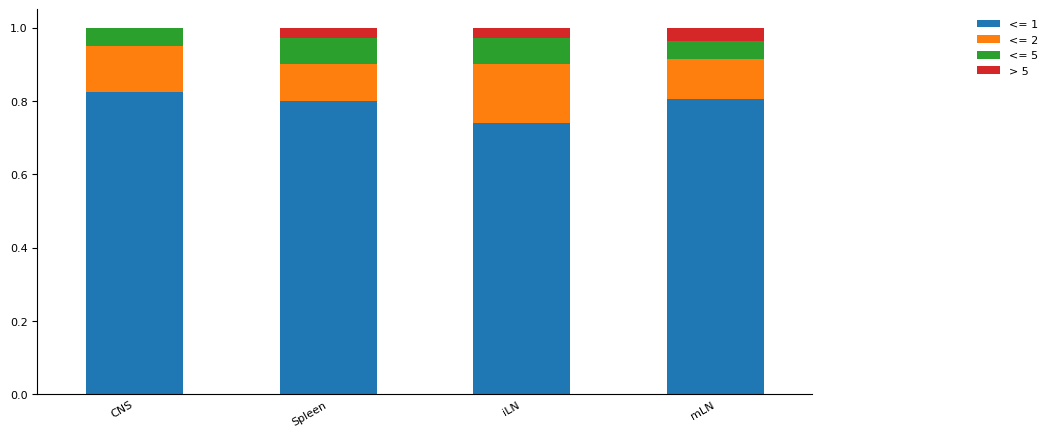

In [51]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby= 'tissue',  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

# TCR embedings

In [52]:
min_clone = 1
cloned_mask = mdata['airr'].obs['clone_id_size'].fillna(0).astype('int') > min_clone
mdata_cloned = mdata[cloned_mask].copy()
mdata_single = mdata[~cloned_mask].copy()
mdata_cloned

MuData object with n_obs × n_vars = 2306 × 30799
  obs:	'batch', 'GSE', 'GSM', 'tissue', 'state', 'cell_type', 'sample_id', 'condition', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call'
  2 modalities
    airr:	2306 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'
    gex:	2306 x 30799
      obs:	'TCR_clonotype_frequency', 'tissue', 'sample_id', 'mouse_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'CD4_score', 'CD8_score', 'cell_type', 'Treg_score', 'Th1_score', 'Th2_score', 'Th17_score', 'Naive_score', 'Cytotoxic_score', 'Exhaustion_core_score', 'Tcf7_stem_score', 'Proliferating_score', 'IFN_stim_score', 'Early_activ_score', 'Memory_core_score', 'Effector_core_score', 'state'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'state_colors', 'cell_type_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'

In [53]:
import importlib
import TCR_embedings
importlib.reload(TCR_embedings)

<module 'TCR_embedings' from '/ihome/ylee/yiz133/Code/Data processing/functions/TCR_embedings.py'>

In [54]:

# Embed TCR AA sequences using Atchley factors and one-hot encoding
tcr_aa_obs = ['VDJ_1_cdr3_aa', 'VJ_1_cdr3_aa']
tcr_cat_features = ['VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call']

mdata = TCR_embedings.embed_tcr_aa(
    mdata,
    tcr_aa_obs=tcr_aa_obs,
    tcr_cat_features=tcr_cat_features,
    min_length=6, 
    max_length=22
)

Stored VDJ_1_cdr3_aa lengths in mdata.obs['VDJ_1_cdr3_aa_length']
Stored VDJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VDJ_1_cdr3_aa_atchley'] with shape (11514, 90)
Stored VDJ_1_cdr3_aa AA composition in mdata.obsm['X_VDJ_1_cdr3_aa_composition'] with shape (11514, 20)

Stored VJ_1_cdr3_aa lengths in mdata.obs['VJ_1_cdr3_aa_length']
Stored VJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VJ_1_cdr3_aa_atchley'] with shape (9784, 90)
Stored VJ_1_cdr3_aa AA composition in mdata.obsm['X_VJ_1_cdr3_aa_composition'] with shape (9784, 20)

VDJ_1_j_call: 12 unique categories + 1 unknown = 13 dimensions
VDJ_1_v_call: 22 unique categories + 1 unknown = 23 dimensions
VJ_1_j_call: 41 unique categories + 1 unknown = 42 dimensions
VJ_1_v_call: 88 unique categories + 1 unknown = 89 dimensions


In [55]:
# Define the TCR obsm keys to include (created by embed_tcr_aa)
tcr_obsm_keys = [
    'X_VDJ_1_cdr3_aa_atchley',
    'X_VDJ_1_cdr3_aa_composition',
    'X_VJ_1_cdr3_aa_atchley',
    'X_VJ_1_cdr3_aa_composition',
    'VDJ_1_j_call',
    'VDJ_1_v_call',
    'VJ_1_j_call',
    'VJ_1_v_call',
]

arrs_tcr = []
for key in tcr_obsm_keys:
    if key in mdata.obsm:
        arrs_tcr.append(mdata.obsm[key])

In [56]:
view_tcr = np.concatenate(arrs_tcr, axis=1)
print(view_tcr.shape)

# Add chain length
for chain in tcr_aa_obs:
    view_tcr = np.concatenate([view_tcr, mdata.obs[chain + '_length'].to_numpy().reshape(-1, 1)],  axis=1)

# Add clone size
view_tcr = np.concatenate([view_tcr, mdata['airr'].obs['clone_id_size'].to_numpy().reshape(-1, 1)],  axis=1)
    
print(view_tcr.shape)

(9784, 387)
(9784, 390)


In [57]:
# ========== VIEW_TCR COLUMN NAMES ==========
# Modify this cell to change column naming conventions
# Note: tcr_obsm_keys is defined in cell 25, edit there to change which obsm arrays are included

view_tcr_colnames = []

# 1. obsm arrays (uses tcr_obsm_keys from cell 25)
for key in tcr_obsm_keys:
    if key in mdata.obsm:
        n_cols = mdata.obsm[key].shape[1]
        for i in range(n_cols):
            view_tcr_colnames.append(f'{key}_{i}')

# 2. Chain lengths (uses tcr_aa_obs from cell 24)
for chain in tcr_aa_obs:
    view_tcr_colnames.append(f'{chain}_length')

# 3. Clone size
view_tcr_colnames.append('clone_id_size')

# Verify
print(f"Number of column names: {len(view_tcr_colnames)}")
print(f"Expected (view_tcr.shape[1]): {view_tcr.shape[1]}")
assert len(view_tcr_colnames) == view_tcr.shape[1], "Column names count mismatch!"
print("\nColumn names preview:")
print(view_tcr_colnames[:10], "...", view_tcr_colnames[-5:])

Number of column names: 390
Expected (view_tcr.shape[1]): 390

Column names preview:
['X_VDJ_1_cdr3_aa_atchley_0', 'X_VDJ_1_cdr3_aa_atchley_1', 'X_VDJ_1_cdr3_aa_atchley_2', 'X_VDJ_1_cdr3_aa_atchley_3', 'X_VDJ_1_cdr3_aa_atchley_4', 'X_VDJ_1_cdr3_aa_atchley_5', 'X_VDJ_1_cdr3_aa_atchley_6', 'X_VDJ_1_cdr3_aa_atchley_7', 'X_VDJ_1_cdr3_aa_atchley_8', 'X_VDJ_1_cdr3_aa_atchley_9'] ... ['VJ_1_v_call_87', 'VJ_1_v_call_88', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length', 'clone_id_size']


In [58]:
# Perform Canonical Correlation Analysis separately on train and test sets
view_gene = mdata['gex'].X.toarray()
# view_gene = mdata['gex'].obsm['X_pca_harmony']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
view_tcr = scaler.fit_transform(view_tcr)
view_gene = scaler.fit_transform(view_gene)

In [59]:
mdata.obsm['tcr_embs'] = view_tcr

In [60]:
mdata_embeded = mdata.copy()

# subset on cells

In [64]:
# Subset on cells where 'clone_id_size' > 1
mask = mdata_embeded['airr'].obs['clone_id_size'] > 1
mdata = mdata_embeded[mask].copy()

# TCR - GEX scores Corr

In [69]:
mdata['gex'].obs['mouse_id'].value_counts()

mouse_id
mouse_1    788
mouse_2    528
mouse_3    527
Name: count, dtype: int64

In [70]:
from scipy.stats import spearmanr, pearsonr
import seaborn as sns

# ========== CORRELATION SETTINGS ==========
# Choose 'spearman' or 'pearson'
corr_method = 'pearson'
# Group by column (set to None to calculate on all data at once)
group_by = 'mouse_id'

# Get all score columns from mdata['gex'].obs
score_cols = [col for col in mdata['gex'].obs.columns if col.endswith('_score')]
print(f"Found {len(score_cols)} score columns: {score_cols}")
print(f"Using {corr_method.upper()} correlation")
print(f"Grouping by: {group_by}\n")

# Extract score values as a matrix
scores_matrix = mdata['gex'].obs[score_cols].values

# Get group labels
if group_by is not None:
    groups = mdata['gex'].obs[group_by].values
    unique_groups = np.unique(groups[~pd.isna(groups)])
    print(f"Found {len(unique_groups)} groups: {unique_groups}")
else:
    unique_groups = ['all']

# Calculate correlation between each TCR column and each score column
n_tcr_cols = view_tcr.shape[1]
n_score_cols = len(score_cols)

# Store correlations per group
corr_per_group = {g: np.zeros((n_tcr_cols, n_score_cols)) for g in unique_groups}
valid_counts = np.zeros((n_tcr_cols, n_score_cols))  # Count how many groups contributed

for g in unique_groups:
    if group_by is not None:
        group_mask = groups == g
    else:
        group_mask = np.ones(len(view_tcr), dtype=bool)
    
    view_tcr_g = view_tcr[group_mask]
    scores_matrix_g = scores_matrix[group_mask]
    
    print(f"  {g}: {group_mask.sum()} cells")
    
    for i in range(n_tcr_cols):
        for j in range(n_score_cols):
            # Handle NaN values
            mask = ~(np.isnan(view_tcr_g[:, i]) | np.isnan(scores_matrix_g[:, j]))
            if mask.sum() > 10:  # Need sufficient points for reliable correlation
                if corr_method == 'spearman':
                    corr, _ = spearmanr(view_tcr_g[mask, i], scores_matrix_g[mask, j])
                else:
                    corr, _ = pearsonr(view_tcr_g[mask, i], scores_matrix_g[mask, j])
                if not np.isnan(corr):
                    corr_per_group[g][i, j] = corr
                    valid_counts[i, j] += 1
                else:
                    corr_per_group[g][i, j] = 0
            else:
                corr_per_group[g][i, j] = 0  # Not enough data

# Average correlations across groups
corr_matrix = np.zeros((n_tcr_cols, n_score_cols))
for g in unique_groups:
    corr_matrix += corr_per_group[g]
corr_matrix = np.divide(corr_matrix, valid_counts, where=valid_counts > 0)
corr_matrix[valid_counts == 0] = np.nan

# Create DataFrames for easier analysis (use descriptive column names)
df_corr = pd.DataFrame(corr_matrix, index=view_tcr_colnames, columns=score_cols)

# Also create per-group dataframes for inspection
df_corr_per_group = {g: pd.DataFrame(corr_per_group[g], index=view_tcr_colnames, columns=score_cols) 
                      for g in unique_groups}

print(f"\n{corr_method.capitalize()} correlation matrix shape: {df_corr.shape}")
print(f"Averaged across {len(unique_groups)} groups")

print(f"\nTop 10 absolute correlations per score column:")
for col in score_cols:
    top_corrs = df_corr[col].abs().nlargest(10)
    print(f"\n{col}:")
    for idx in top_corrs.index:
        print(f"  {idx}: r={df_corr.loc[idx, col]:.4f}")

Found 15 score columns: ['CD4_score', 'CD8_score', 'Treg_score', 'Th1_score', 'Th2_score', 'Th17_score', 'Naive_score', 'Cytotoxic_score', 'Exhaustion_core_score', 'Tcf7_stem_score', 'Proliferating_score', 'IFN_stim_score', 'Early_activ_score', 'Memory_core_score', 'Effector_core_score']
Using PEARSON correlation
Grouping by: mouse_id

Found 3 groups: ['mouse_1' 'mouse_2' 'mouse_3']


IndexError: boolean index did not match indexed array along dimension 0; dimension is 9784 but corresponding boolean dimension is 2086

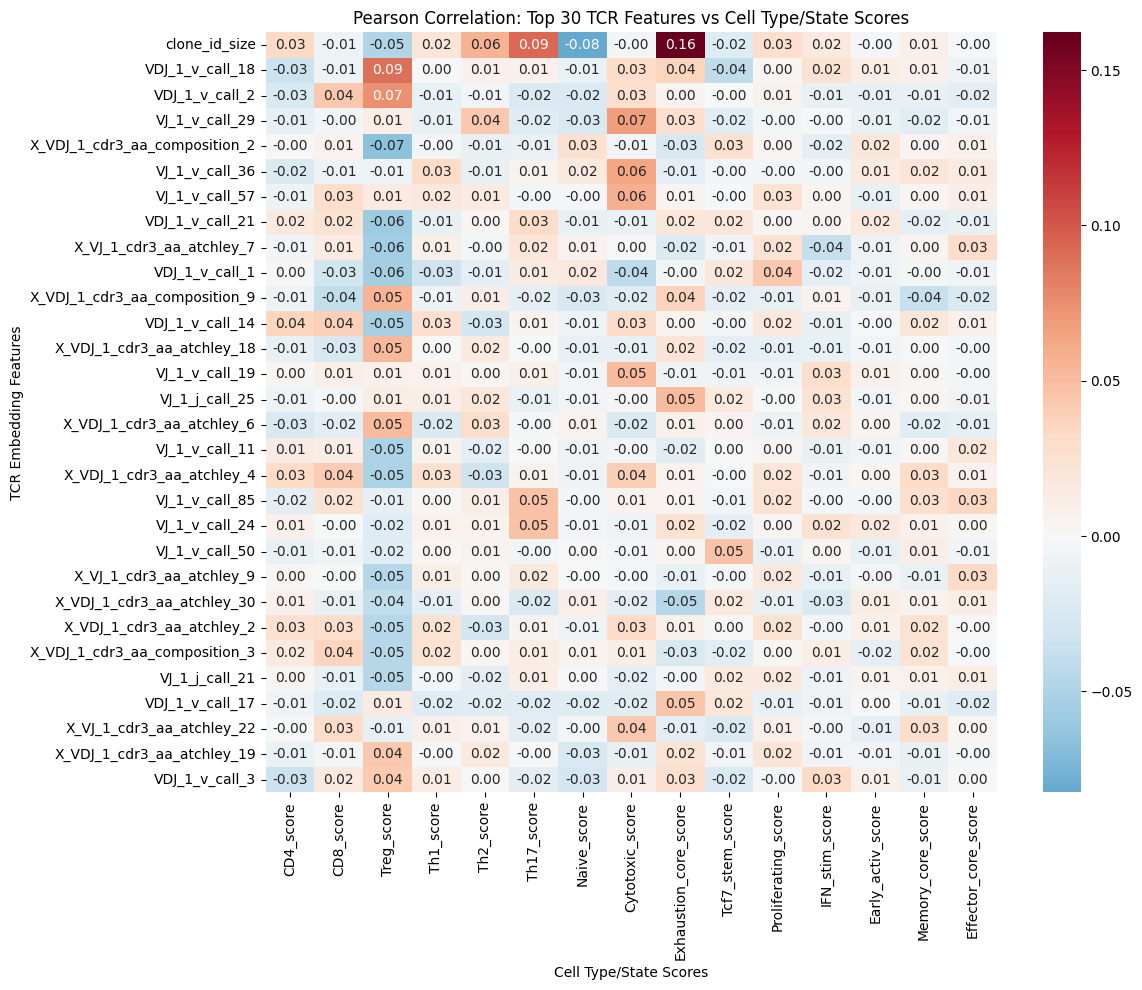

NameError: name 'df_pval' is not defined

In [ ]:
# Plot heatmap of top correlated TCR features per score
# Select top N most variable TCR features across all scores
n_top = 30
tcr_var = df_corr.abs().max(axis=1)
top_tcr_idx = tcr_var.nlargest(n_top).index

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    df_corr.loc[top_tcr_idx], 
    cmap='RdBu_r', 
    center=0, 
    annot=True, 
    fmt='.2f',
    xticklabels=True,
    yticklabels=True,
    ax=ax
)
ax.set_title(f'{corr_method.capitalize()} Correlation: Top {n_top} TCR Features vs Cell Type/State Scores')
ax.set_xlabel('Cell Type/State Scores')
ax.set_ylabel('TCR Embedding Features')
plt.tight_layout()
plt.show()

# # Summary: Count significant correlations (p < 0.05) per score column
# sig_threshold = 0.05
# sig_counts = (df_pval < sig_threshold).sum()
# print(f"\nNumber of significant TCR features (p < 0.05) per score ({corr_method}):")
# print(sig_counts.sort_values(ascending=False))

# Tissue specific genes within sub-type

In [ ]:
mdata['gex'].obs['tissue'].value_counts()

tissue
iLN       2719
mLN       2524
Spleen    2034
CNS        307
Name: count, dtype: int64

In [ ]:
# ========== TREG DEG CORRELATION ANALYSIS ==========
# Settings
treg_threshold = 0.5
n_top_degs = 20
corr_method_deg = 'pearson'  # 'spearman' or 'pearson'

# Subset to Treg cells (Treg_score > threshold)
treg_mask = mdata['gex'].obs['Treg_score'] > treg_threshold
adata_treg = mdata['gex'][treg_mask].copy()
print(f"Treg cells (score > {treg_threshold}): {adata_treg.n_obs}")

# Get unique tissues and mouse_ids
tissues = adata_treg.obs['tissue'].dropna().unique()
mouse_ids = adata_treg.obs['mouse_id'].dropna().unique()
print(f"Tissues: {tissues}")
print(f"Mouse IDs: {mouse_ids}")

# Find DEGs for each tissue (across all Treg cells)
print(f"\n--- Finding top {n_top_degs} DEGs per tissue ---")
sc.tl.rank_genes_groups(adata_treg, groupby='tissue', method='wilcoxon', n_genes=n_top_degs)

# Collect top DEGs per tissue
deg_genes_per_tissue = {}
all_deg_genes = set()
for tissue in tissues:
    try:
        genes = sc.get.rank_genes_groups_df(adata_treg, group=tissue).head(n_top_degs)['names'].tolist()
        deg_genes_per_tissue[tissue] = genes
        all_deg_genes.update(genes)
        print(f"  {tissue}: {len(genes)} DEGs")
    except:
        print(f"  {tissue}: No DEGs found")
        deg_genes_per_tissue[tissue] = []

all_deg_genes = list(all_deg_genes)
print(f"\nTotal unique DEGs across tissues: {len(all_deg_genes)}")

Treg cells (score > 0.5): 938
Tissues: ['iLN', 'CNS', 'Spleen', 'mLN']
Categories (4, object): ['CNS', 'Spleen', 'iLN', 'mLN']
Mouse IDs: ['mouse_1', 'mouse_2', 'mouse_3']
Categories (3, object): ['mouse_1', 'mouse_2', 'mouse_3']

--- Finding top 20 DEGs per tissue ---
  iLN: 20 DEGs
  CNS: 20 DEGs
  Spleen: 20 DEGs
  mLN: 20 DEGs

Total unique DEGs across tissues: 77


In [ ]:
# ========== Calculate TCR-DEG correlation per mouse, then average ==========

# Get the TCR embeddings for Treg cells only
# Need to match indices
treg_indices = np.where(treg_mask)[0]
view_tcr_treg = view_tcr[treg_indices]
view_tcr_colnames_treg = view_tcr_colnames  # Same column names

# Get DEG expression matrix for Treg cells
deg_expr = adata_treg[:, all_deg_genes].X
if hasattr(deg_expr, 'toarray'):
    deg_expr = deg_expr.toarray()

print(f"TCR embeddings shape (Treg): {view_tcr_treg.shape}")
print(f"DEG expression shape: {deg_expr.shape}")

# Get mouse_ids for Treg cells
mouse_ids_treg = adata_treg.obs['mouse_id'].values

# Calculate correlation per mouse and average
n_tcr_cols = view_tcr_treg.shape[1]
n_deg_cols = len(all_deg_genes)

corr_per_mouse = {m: np.zeros((n_tcr_cols, n_deg_cols)) for m in mouse_ids}
valid_counts_deg = np.zeros((n_tcr_cols, n_deg_cols))

print(f"\n--- Calculating correlations per mouse ---")
for m in mouse_ids:
    mouse_mask = mouse_ids_treg == m
    n_cells = mouse_mask.sum()
    print(f"  {m}: {n_cells} Treg cells")
    
    if n_cells < 20:
        print(f"    Skipping (too few cells)")
        continue
    
    view_tcr_m = view_tcr_treg[mouse_mask]
    deg_expr_m = deg_expr[mouse_mask]
    
    for i in range(n_tcr_cols):
        for j in range(n_deg_cols):
            mask = ~(np.isnan(view_tcr_m[:, i]) | np.isnan(deg_expr_m[:, j]))
            if mask.sum() > 10:
                if corr_method_deg == 'spearman':
                    corr, _ = spearmanr(view_tcr_m[mask, i], deg_expr_m[mask, j])
                else:
                    corr, _ = pearsonr(view_tcr_m[mask, i], deg_expr_m[mask, j])
                if not np.isnan(corr):
                    corr_per_mouse[m][i, j] = corr
                    valid_counts_deg[i, j] += 1

# Average across mice
corr_matrix_deg = np.zeros((n_tcr_cols, n_deg_cols))
for m in mouse_ids:
    corr_matrix_deg += corr_per_mouse[m]
corr_matrix_deg = np.divide(corr_matrix_deg, valid_counts_deg, where=valid_counts_deg > 0)
corr_matrix_deg[valid_counts_deg == 0] = np.nan

# Create DataFrame
df_corr_deg = pd.DataFrame(corr_matrix_deg, index=view_tcr_colnames, columns=all_deg_genes)

print(f"\nTCR-DEG correlation matrix shape: {df_corr_deg.shape}")
print(f"Averaged across {len(mouse_ids)} mice")

TCR embeddings shape (Treg): (938, 390)
DEG expression shape: (938, 77)

--- Calculating correlations per mouse ---
  mouse_1: 209 Treg cells
  mouse_2: 200 Treg cells
  mouse_3: 286 Treg cells

TCR-DEG correlation matrix shape: (390, 77)
Averaged across 3 mice


Top 5 TCR features correlated with each tissue-specific DEG:

=== iLN DEGs ===
  Rps29:
    VJ_1_v_call_63: r=-0.1357
    clone_id_size: r=-0.1313
    VJ_1_v_call_9: r=-0.1241
  Cd74:
    VJ_1_v_call_40: r=0.1587
    VJ_1_v_call_50: r=0.1294
    X_VJ_1_cdr3_aa_atchley_43: r=0.1163
  Rpl41:
    VJ_1_v_call_63: r=-0.1651
    VJ_1_v_call_8: r=-0.1195
    X_VJ_1_cdr3_aa_atchley_17: r=-0.1130
  Rpl36:
    VJ_1_v_call_52: r=-0.1614
    VJ_1_v_call_76: r=-0.1537
    VJ_1_j_call_27: r=0.1156
  Rpl37a:
    VJ_1_v_call_8: r=-0.1237
    clone_id_size: r=-0.1172
    VJ_1_v_call_6: r=0.1170

=== CNS DEGs ===
  Ifngr1:
    VJ_1_v_call_12: r=0.1624
    VJ_1_v_call_9: r=0.1341
    X_VJ_1_cdr3_aa_atchley_68: r=-0.1166
  Actg1:
    VJ_1_v_call_9: r=0.1637
    X_VDJ_1_cdr3_aa_composition_1: r=-0.1449
    VDJ_1_v_call_0: r=-0.1366
  Aldoa:
    VJ_1_v_call_17: r=0.1340
    VJ_1_v_call_63: r=0.1279
    X_VDJ_1_cdr3_aa_atchley_35: r=-0.1037
  Tmsb4x:
    VJ_1_v_call_17: r=-0.1866
    VJ_1_v_call_8: r=-0.1527

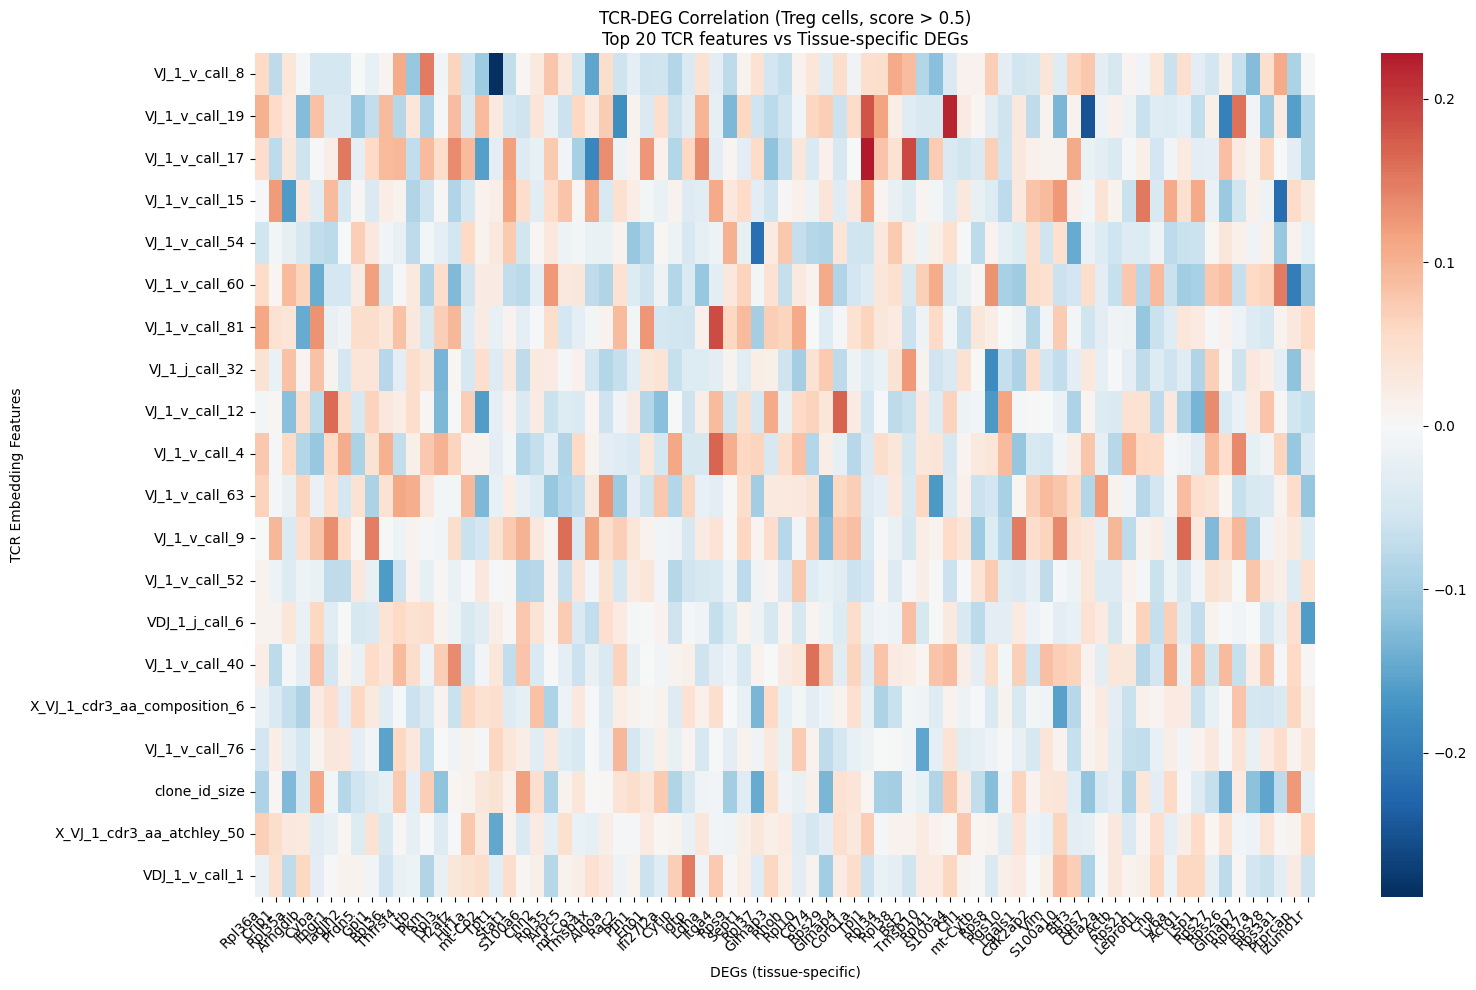

In [ ]:
# ========== Visualize TCR-DEG correlations ==========

# Top correlated TCR features for each DEG
print("Top 5 TCR features correlated with each tissue-specific DEG:\n")
for tissue, genes in deg_genes_per_tissue.items():
    print(f"=== {tissue} DEGs ===")
    for gene in genes[:5]:  # Show first 5 genes per tissue
        if gene in df_corr_deg.columns:
            top_tcr = df_corr_deg[gene].abs().nlargest(3)
            print(f"  {gene}:")
            for tcr_feat in top_tcr.index:
                print(f"    {tcr_feat}: r={df_corr_deg.loc[tcr_feat, gene]:.4f}")
    print()

# Heatmap of top variable TCR features vs DEGs
n_top_tcr = 20
tcr_var_deg = df_corr_deg.abs().max(axis=1)
top_tcr_idx_deg = tcr_var_deg.nlargest(n_top_tcr).index

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    df_corr_deg.loc[top_tcr_idx_deg], 
    cmap='RdBu_r', 
    center=0, 
    xticklabels=True,
    yticklabels=True,
    ax=ax
)
ax.set_title(f'TCR-DEG Correlation (Treg cells, score > {treg_threshold})\nTop {n_top_tcr} TCR features vs Tissue-specific DEGs')
ax.set_xlabel('DEGs (tissue-specific)')
ax.set_ylabel('TCR Embedding Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
aa

NameError: name 'aa' is not defined

In [ ]:
# mdata.write('yz_processed.h5mu')
# mdata.write('yz_processed_allGenes_annotateByRef.h5mu')
mdata.write('yz_processed_allGenes_annotateByScore.h5mu')